In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

%matplotlib widget

def pcm_to_pdm(pcm_signal, osr):
    data_upsampled = np.repeat(pcm_signal, osr)
    n_samples = len(data_upsampled)
    pdm_bitstream = np.empty(n_samples)
    integrator = 0.0
    
    for i in range(n_samples):
        output = 1.0 if integrator >= 0 else -1.0
        pdm_bitstream[i] = output
        integrator += (data_upsampled[i] - output)
    return pdm_bitstream

filename = "pdm32bits-rtos_5khz_alto01.RAW"
fs = 5e6
fc = 9e4
decim = 16
order = 2

# data
data = np.fromfile(filename, dtype=np.uint32)
data = data[len(data)//2:]
data = data.byteswap()
data2 = data.view(np.uint8)
bits = np.unpackbits(data2)
pdm_signal = 2 * bits.astype(np.float64) - 1

# filtragem
norm_fc = fc / (fs * 0.5)
b, a = butter(N=order, Wn=norm_fc, btype='low')
filtered_data = filtfilt(b, a, pdm_signal)
fs_decim = int(fs / decim)
pcm_signal = filtered_data[::decim]

t = np.arange(len(pcm_signal))/fs_decim
wave = np.sin(2*np.pi*75000*t)/100
sum_wave = (wave + pcm_signal)
pdm_result = pcm_to_pdm(sum_wave, 16)

N = len(pdm_result)
spec = np.abs(np.fft.rfft(pdm_result))
freq = np.fft.rfftfreq(N, 1/fs)

def plot(spec, freq):
    # plot
    fig, ax = plt.subplots()
    ax.semilogx(freq, 20*np.log10(spec), linewidth=0.5)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title('Espectro de Frequência (FFT)')
    plt.grid(True, which="both", linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


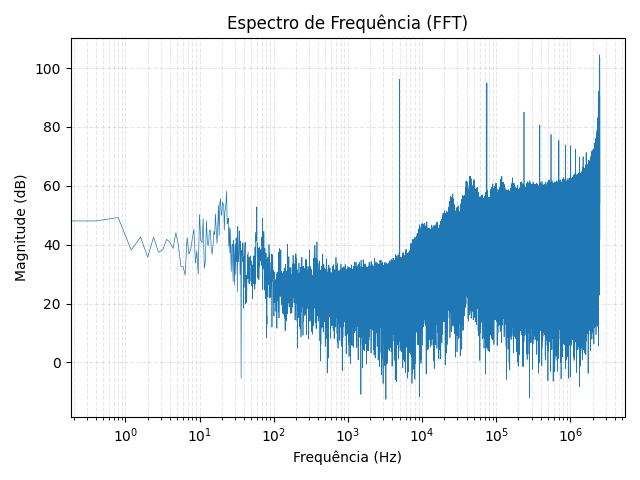

In [ ]:
pdm_result.tofile("good75k.raw", format='raw')
plot(spec, freq)